# Числове дослідження МНС і ПАРТАН-МНС

Блокнот оформлено як серію експериментів: для кожного параметра будується таблиця, графіки та короткий висновок. Окремо досліджується безумовна оптимізація та умовна оптимізація методом зовнішніх штрафних функцій.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "optimization").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import optimization.experiments as experiments
experiments = importlib.reload(experiments)

BASE_PARAMS = experiments.BASE_PARAMS
EXPERIMENTS = experiments.EXPERIMENTS
METHODS = experiments.METHODS
DISPLAY_COLUMN_LABELS = experiments.DISPLAY_COLUMN_LABELS
compare_methods = experiments.compare_methods
compare_penalty_methods = experiments.compare_penalty_methods
compare_penalty_start_points = experiments.compare_penalty_start_points
distance_to_circle_boundary = experiments.distance_to_circle_boundary
format_point = experiments.format_point
old_sympy_check = experiments.old_sympy_check
penalty_experiment_summary = experiments.penalty_experiment_summary
sympy_penalty_s4_check = experiments.sympy_penalty_s4_check
sweep = experiments.sweep

from optimization.functions import F_MIN, FUNCTION_FORMULA, X_MIN, X_START, power_function
from optimization.partan_steepest_descent import partan_steepest_descent
from optimization.penalty import circle_constraint, make_external_penalty_function
import optimization.plots as plots
plots = importlib.reload(plots)
plot_circle_constraint = plots.plot_circle_constraint
plot_final_comparison = plots.plot_final_comparison
plot_metric_by_parameter = plots.plot_metric_by_parameter
plot_penalty_trajectory = plots.plot_penalty_trajectory
plot_trajectory = plots.plot_trajectory
from optimization.steepest_descent import steepest_descent

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (8, 4)

base_params = dict(BASE_PARAMS)
base_params

{'max_iter': 1000,
 'eps': 1e-06,
 'derivative_h': 0.0001,
 'gradient_scheme': 'central',
 'line_search_method': 'golden',
 'line_search_eps': 1e-12,
 'sven_alpha': 0.01,
 'stop_criterion': 'combined'}

In [2]:
COLUMN_LABELS = {
    "task": "задача",
    "method": "метод",
    "parameter_value": "значення параметра",
    "x_final": "кінцева точка",
    "f_final": "кінцеве значення функції",
    "grad_norm_final": "норма градієнта",
    "iterations": "кількість ітерацій",
    "func_calls": "кількість викликів функції",
    "status": "статус",
}
COLUMN_LABELS.update(DISPLAY_COLUMN_LABELS)

PARAMETER_LABELS = {
    "derivative_h": "крок h",
    "gradient_scheme": "схема чисельного диференціювання",
    "line_search_method": "метод одновимірного пошуку",
    "line_search_eps": "точність одновимірного пошуку",
    "sven_alpha": "параметр α методу Свена",
    "stop_criterion": "критерій зупинки",
}

CONCLUSIONS = {
    "derivative_h": "Малий крок дає точніше чисельне наближення похідної, але може збільшувати кількість обчислень або викликати числову нестабільність. Надто великий крок може давати грубе наближення градієнта.",
    "gradient_scheme": "Центральна схема зазвичай дає точніше наближення похідної, але може потребувати більше викликів функції, бо для кожної координати функція обчислюється з двох боків.",
    "line_search_method": "Метод одновимірного пошуку впливає не тільки на точність вибору кроку λ, але й на загальну кількість викликів цільової функції.",
    "line_search_eps": "Занадто груба точність одновимірного пошуку може погіршити кінцеву точність, а занадто мала точність може збільшити кількість викликів функції без суттєвого покращення результату.",
    "sven_alpha": "Параметр Свена впливає на початкову локалізацію інтервалу для одновимірного пошуку. Невдале значення може збільшити кількість обчислень функції.",
    "stop_criterion": "Комбінований критерій враховує не тільки норму градієнта, але й зміну точки або значення функції, тому може бути практичнішим для чисельних методів.",
}


def format_vector(x):
    arr = np.asarray(x, dtype=float).reshape(-1)
    return "[" + ", ".join(f"{value:.8f}" for value in arr) + "]"


def parse_point(value):
    if isinstance(value, str):
        return np.fromstring(value.strip("[]"), sep=",")
    return np.asarray(value, dtype=float).reshape(-1)


def format_display_value(value):
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.6e}"
    return value


def show_table(df):
    formatted = df.copy()
    for column in formatted.columns:
        formatted[column] = formatted[column].map(format_display_value)
    display(formatted.rename(columns=COLUMN_LABELS))


def sweep_table(parameter_name):
    frames = []
    for method_name, method_fn in METHODS.items():
        df = sweep(method_fn, parameter_name, EXPERIMENTS[parameter_name], base_params=base_params)
        df.insert(0, "method", method_name)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def show_sweep(parameter_name, title):
    table = sweep_table(parameter_name)
    display(Markdown(f"### {title}"))
    show_table(table)

    log_x = parameter_name in {"derivative_h", "line_search_eps", "sven_alpha"}
    xlabel = PARAMETER_LABELS.get(parameter_name, parameter_name)
    metrics = [
        ("iterations", "кількість ітерацій", False),
        ("func_calls", "кількість викликів функції", False),
        ("x_error", "відстань до точного мінімуму", True),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, (metric, ylabel, log_y) in zip(axes.ravel(), metrics):
        plot_metric_by_parameter(
            table,
            parameter_col="parameter_value",
            metric_col=metric,
            title=f"{xlabel} -> {ylabel}",
            xlabel=xlabel,
            ylabel=ylabel,
            log_x=log_x,
            log_y=log_y,
            ax=ax,
        )
    plt.tight_layout()
    plt.show()
    display(Markdown(f"**Висновок.** {CONCLUSIONS[parameter_name]}"))
    return table


def contour_grid(points):
    pts = np.asarray(points, dtype=float)
    x_min = min(float(pts[:, 0].min()), -1.5) - 0.25
    x_max = max(float(pts[:, 0].max()), 1.2) + 0.25
    y_min = min(float(pts[:, 1].min()), -0.5) - 0.25
    y_max = max(float(pts[:, 1].max()), 1.2) + 0.25
    x1 = np.linspace(x_min, x_max, 260)
    x2 = np.linspace(y_min, y_max, 260)
    X, Y = np.meshgrid(x1, x2)
    Z = np.vectorize(lambda a, b: power_function(np.array([a, b], dtype=float)))(X, Y)
    return X, Y, Z


def plot_combined_trajectories(results, title):
    all_points = np.vstack([result["points"] for result in results.values()])
    X, Y, Z = contour_grid(all_points)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X, Y, Z, levels=28, cmap="viridis", alpha=0.65)
    colors = {"МНС": "tab:blue", "ПАРТАН-МНС": "tab:orange"}
    for method_name, result in results.items():
        points = np.asarray(result["points"], dtype=float)
        ax.plot(points[:, 0], points[:, 1], "o-", linewidth=1.8, markersize=4.5, color=colors[method_name], label=method_name)
        ax.scatter(points[-1, 0], points[-1, 1], s=85, color=colors[method_name], edgecolor="black", linewidth=1.0)
    ax.scatter([X_START[0]], [X_START[1]], marker="s", s=60, color="tab:purple", label="стартова точка")
    ax.scatter([X_MIN[0]], [X_MIN[1]], marker="*", s=120, color="tab:green", label="очікуваний мінімум")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2. Початкова функція та стартові дані

,назва,значення
0,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
1,x_start,"[-1.20000000, 0.00000000]"
2,x_min,"[1.00000000, 1.00000000]"
3,f_min,0.0
4,f(x_start),137031.455542


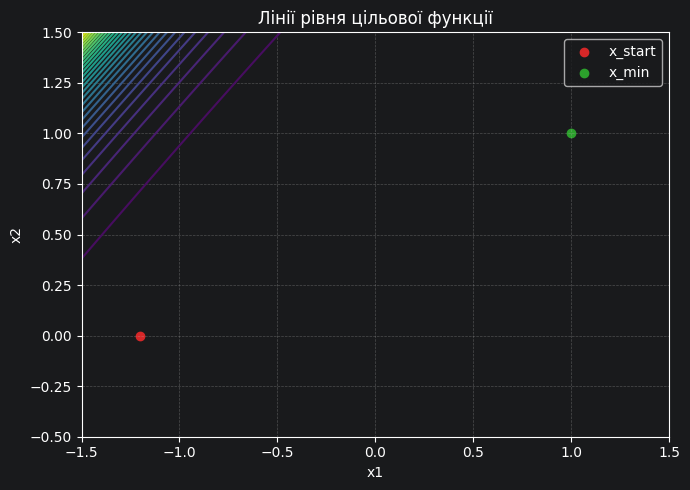

In [3]:
initial_table = pd.DataFrame([
    {"назва": "функція", "значення": FUNCTION_FORMULA},
    {"назва": "x_start", "значення": format_vector(X_START)},
    {"назва": "x_min", "значення": format_vector(X_MIN)},
    {"назва": "f_min", "значення": F_MIN},
    {"назва": "f(x_start)", "значення": power_function(X_START)},
])
display(initial_table)

x1 = np.linspace(-1.5, 1.5, 260)
x2 = np.linspace(-0.5, 1.5, 260)
X, Y = np.meshgrid(x1, x2)
Z = np.vectorize(lambda a, b: power_function(np.array([a, b], dtype=float)))(X, Y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.contour(X, Y, Z, levels=30, cmap="viridis")
ax.scatter([X_START[0]], [X_START[1]], color="tab:red", label="x_start")
ax.scatter([X_MIN[0]], [X_MIN[1]], color="tab:green", label="x_min")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Лінії рівня цільової функції")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Пояснення чисельних методів

У роботі похідні обчислюються чисельно. Порівнюються пряма, зворотна та центральна схеми. Центральна схема зазвичай точніша, але потребує більше викликів функції.

На кожній ітерації напрямок спуску уточнюється одновимірним пошуком. Спочатку метод Свена знаходить інтервал, після чого мінімум шукається методом золотого перетину або методом ДСК-Пауелла. Точність `line_search_eps` важлива, бо для степеневої функції оптимальний крок може бути дуже малим.

Для штрафної функції використовується комбінований критерій зупинки, бо поблизу межі області градієнт штрафу може поводитися жорстко, хоча точка вже майже не змінюється.

## 4. Безумовна оптимізація

### 4.1. Вплив кроку чисельного диференціювання h

,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,1.000000e-01,"[0.99999961, 0.99999959]",6.026396e-52,2.491987e-09,5.666816e-07,13,1052,збіжність
1,МНС,1.000000e-02,"[0.99999950, 0.99999947]",4.529565e-51,3.207101e-15,7.291919e-07,13,3087,збіжність
2,МНС,1.000000e-03,"[0.99746460, 0.99731885]",1.944677e-21,7.331489e-17,3.690094e-03,8,1227,збіжність
3,МНС,1.000000e-04,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,3.897180e-03,8,1227,збіжність
4,МНС,1.000000e-05,"[0.99731589, 0.99717042]",3.024783e-21,6.217427e-18,3.900125e-03,8,1228,збіжність
5,МНС,1.000000e-06,"[0.99731582, 0.99717035]",3.025398e-21,6.215851e-18,3.900224e-03,8,1227,збіжність
6,ПАРТАН-МНС,1.000000e-01,"[1.00510171, 1.00529439]",4.856567e-19,3.718265e-05,7.352415e-03,5,337,збіжність
7,ПАРТАН-МНС,1.000000e-02,"[1.00006813, 1.00007069]",4.909326e-34,4.964713e-13,9.817761e-05,5,568,збіжність
8,ПАРТАН-МНС,1.000000e-03,"[0.99999162, 0.99999008]",7.782443e-41,1.437293e-19,1.298969e-05,4,199,збіжність
9,ПАРТАН-МНС,1.000000e-04,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,1.730776e-05,4,199,збіжність


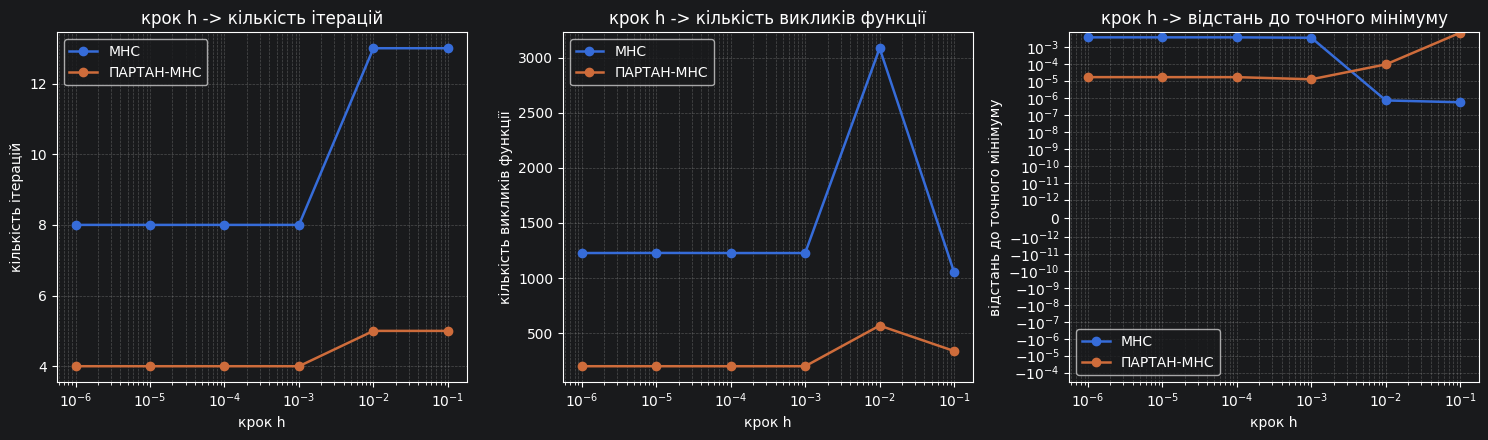

**Висновок.** Малий крок дає точніше чисельне наближення похідної, але може збільшувати кількість обчислень або викликати числову нестабільність. Надто великий крок може давати грубе наближення градієнта.

In [4]:
h_table = show_sweep("derivative_h", "4.1. Вплив кроку чисельного диференціювання h")

### 4.2. Вплив схеми чисельного диференціювання

,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,forward,"[0.99738633, 0.99909895]",1.710078e-18,9.882036e-15,2.764627e-03,7,908,збіжність
1,МНС,backward,"[0.99637400, 0.99615565]",3.445901e-20,7.134776e-17,5.284594e-03,8,1218,збіжність
2,МНС,central,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,3.897180e-03,8,1227,збіжність
3,ПАРТАН-МНС,forward,"[1.00047472, 1.00056177]",8.224211e-27,1.013597e-21,7.354887e-04,4,194,збіжність
4,ПАРТАН-МНС,backward,"[0.99953942, 0.99945500]",6.450387e-27,8.662469e-22,7.135546e-04,4,194,збіжність
5,ПАРТАН-МНС,central,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,1.730776e-05,4,199,збіжність


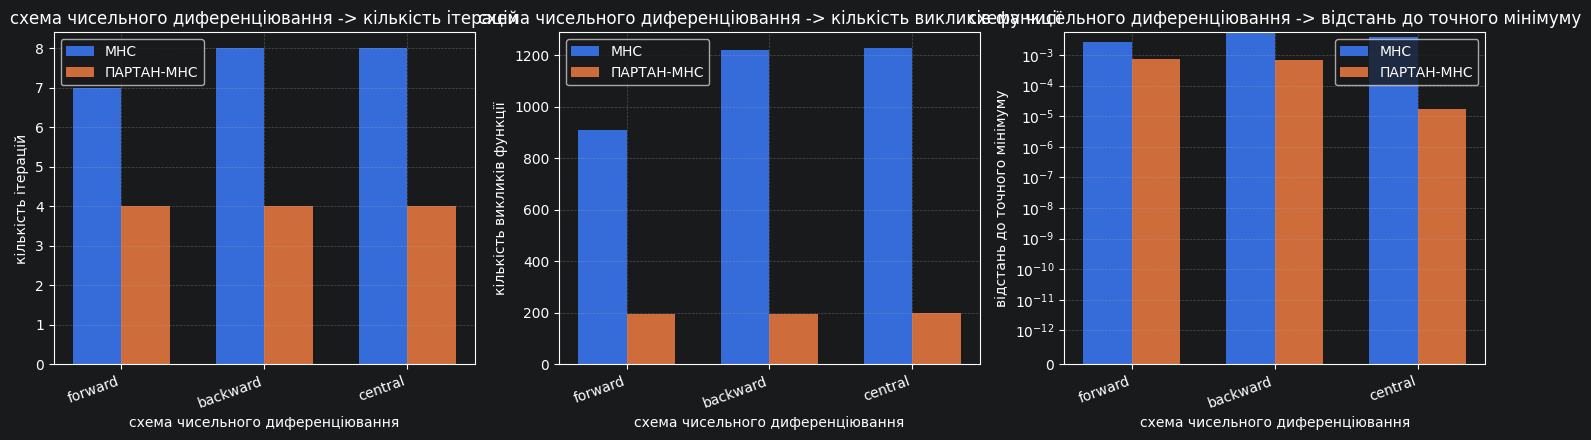

**Висновок.** Центральна схема зазвичай дає точніше наближення похідної, але може потребувати більше викликів функції, бо для кожної координати функція обчислюється з двох боків.

In [5]:
scheme_table = show_sweep("gradient_scheme", "4.2. Вплив схеми чисельного диференціювання")

### 4.3. Вплив методу одновимірного пошуку

,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,golden,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,3.897180e-03,8,1227,збіжність
1,МНС,dsk_powell,"[0.99728251, 0.99713635]",3.333343e-21,7.054293e-18,3.947811e-03,8,170,збіжність
2,ПАРТАН-МНС,golden,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,1.730776e-05,4,199,збіжність
3,ПАРТАН-МНС,dsk_powell,"[1.00295650, 1.00132314]",1.573880e-18,9.160404e-15,3.239068e-03,4,86,збіжність


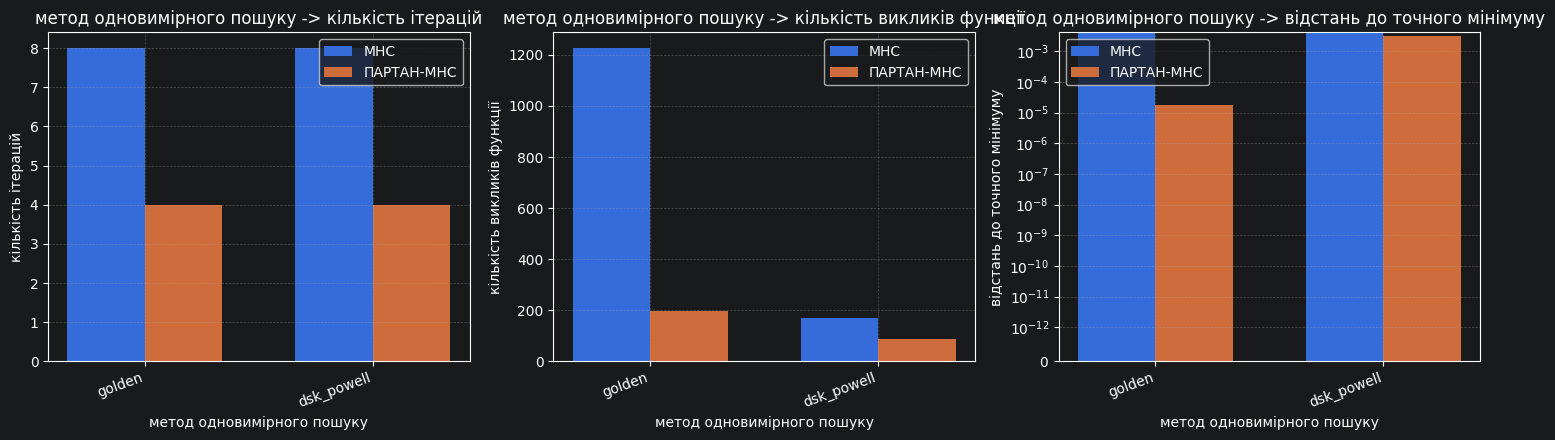

**Висновок.** Метод одновимірного пошуку впливає не тільки на точність вибору кроку λ, але й на загальну кількість викликів цільової функції.

In [6]:
line_search_method_table = show_sweep("line_search_method", "4.3. Вплив методу одновимірного пошуку")

### 4.4. Вплив точності одновимірного пошуку

,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,1.000000e-01,"[0.99267733, 0.99241785]",8.690281e-18,6.948585e-15,1.054090e-02,53,1852,збіжність
1,МНС,1.000000e-02,"[0.99318875, 0.99299724]",4.780737e-18,4.331862e-15,9.768920e-03,73,3163,збіжність
2,МНС,1.000000e-03,"[0.99296606, 0.99224505]",8.936169e-18,9.488669e-15,1.046975e-02,114,5513,збіжність
3,МНС,1.000000e-04,"[0.99318193, 0.99255316]",6.472691e-18,6.520541e-15,1.009660e-02,110,5862,збіжність
4,МНС,1.000000e-06,"[0.99307912, 0.99262229]",6.242794e-18,5.167019e-15,1.011580e-02,39,3029,збіжність
5,МНС,1.000000e-08,"[0.99348915, 0.99312476]",3.653237e-18,3.122371e-15,9.468896e-03,10,1052,збіжність
6,МНС,1.000000e-10,"[0.99723457, 0.99708448]",3.841807e-21,7.979663e-18,4.018443e-03,8,964,збіжність
7,МНС,1.000000e-12,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,3.897180e-03,8,1227,збіжність
8,ПАРТАН-МНС,1.000000e-01,"[0.99926127, 0.99819038]",2.083157e-20,2.144214e-16,1.954591e-03,32,641,збіжність
9,ПАРТАН-МНС,1.000000e-02,"[1.00013185, 1.00024626]",4.835192e-28,3.433341e-22,2.793338e-04,34,812,збіжність


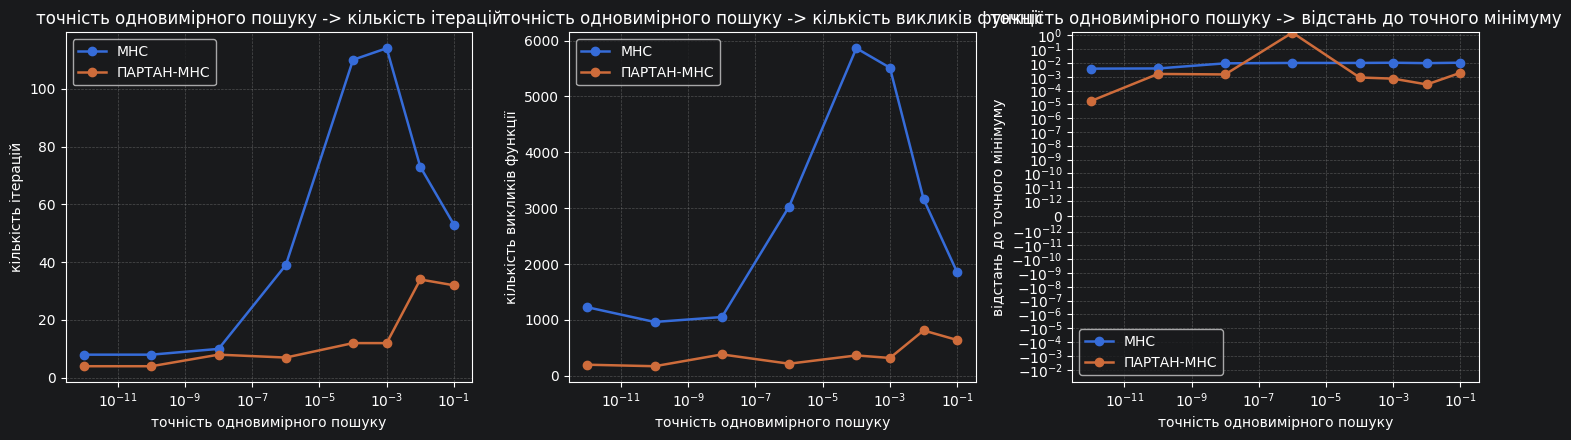

**Висновок.** Занадто груба точність одновимірного пошуку може погіршити кінцеву точність, а занадто мала точність може збільшити кількість викликів функції без суттєвого покращення результату.

In [7]:
line_search_eps_table = show_sweep("line_search_eps", "4.4. Вплив точності одновимірного пошуку")

### 4.5. Вплив параметра методу Свена

,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,1.000000e-03,"[0.99731818, 0.99717267]",3.005004e-21,6.452586e-18,3.896922e-03,8,1249,збіжність
1,МНС,5.000000e-03,"[0.99731931, 0.99717386]",2.994874e-21,6.433781e-18,3.895277e-03,8,1231,збіжність
2,МНС,1.000000e-02,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,3.897180e-03,8,1227,збіжність
3,МНС,5.000000e-02,"[0.99731781, 0.99717228]",3.008259e-21,6.458628e-18,3.897449e-03,8,1217,збіжність
4,МНС,1.000000e-01,"[0.99731829, 0.99717279]",3.003962e-21,6.450653e-18,3.896753e-03,8,1218,збіжність
5,МНС,5.000000e-01,"[0.99731981, 0.99717438]",2.990429e-21,6.425527e-18,3.894554e-03,8,1208,збіжність
6,МНС,1.000000e+00,"[0.99731824, 0.99717273]",3.004412e-21,6.451489e-18,3.896826e-03,8,1214,збіжність
7,ПАРТАН-МНС,1.000000e-03,"[0.99999073, 0.99998903]",1.742062e-40,1.596321e-25,1.436622e-05,4,208,збіжність
8,ПАРТАН-МНС,5.000000e-03,"[1.00000522, 1.00000618]",1.756083e-42,8.959802e-26,8.086804e-06,4,202,збіжність
9,ПАРТАН-МНС,1.000000e-02,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,1.730776e-05,4,199,збіжність


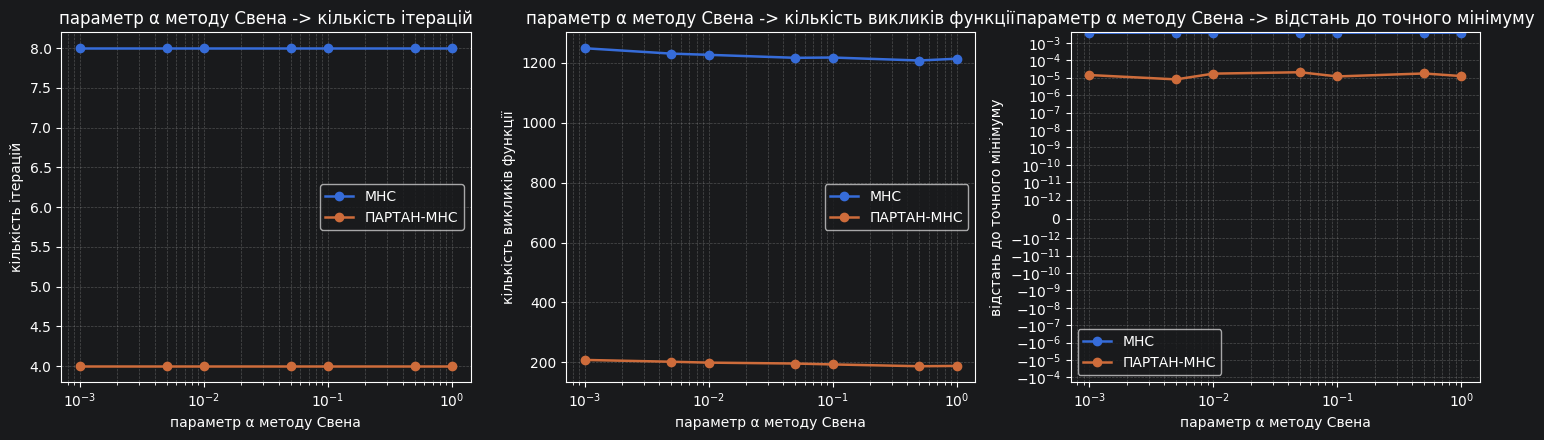

**Висновок.** Параметр Свена впливає на початкову локалізацію інтервалу для одновимірного пошуку. Невдале значення може збільшити кількість обчислень функції.

In [8]:
sven_alpha_table = show_sweep("sven_alpha", "4.5. Вплив параметра методу Свена")

### 4.6. Вплив критерію зупинки

,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,gradient,"[0.96765174, 0.98529542]",2.993129e-10,1.573902e-07,3.553357e-02,5,289,збіжність
1,МНС,combined,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,3.897180e-03,8,1227,збіжність
2,ПАРТАН-МНС,gradient,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,1.730776e-05,4,199,збіжність
3,ПАРТАН-МНС,combined,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,1.730776e-05,4,199,збіжність


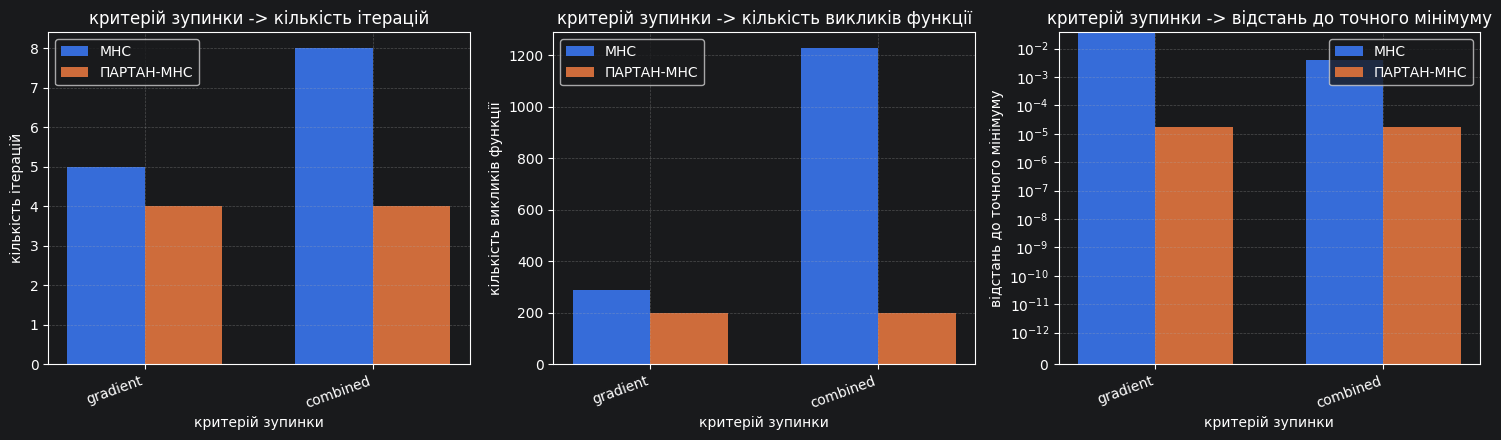

**Висновок.** Комбінований критерій враховує не тільки норму градієнта, але й зміну точки або значення функції, тому може бути практичнішим для чисельних методів.

In [9]:
stop_criterion_table = show_sweep("stop_criterion", "4.6. Вплив критерію зупинки")

### 4.7. Порівняння МНС і ПАРТАН-МНС

,метод,кінцева точка,кінцеве значення функції,норма градієнта,кількість ітерацій,кількість викликів функції,статус
0,МНС,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,8,1227,збіжність
1,ПАРТАН-МНС,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,4,199,збіжність


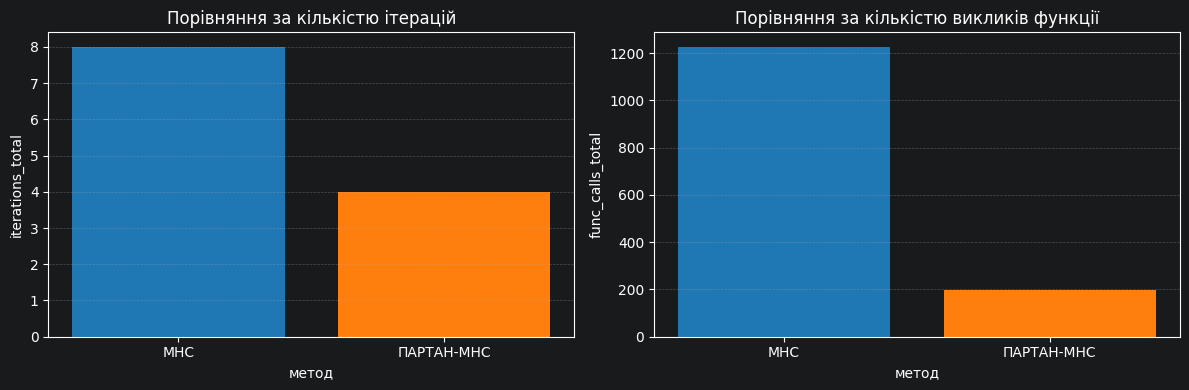

**Висновок.** Порівняння показує різницю між методами за кількістю ітерацій, викликів функції та точністю фінальної точки.

In [10]:
comparison_table = compare_methods(base_params)
show_table(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_final_comparison(comparison_table.rename(columns={"iterations": "iterations_total"}), "iterations_total", "Порівняння за кількістю ітерацій", ax=axes[0])
plot_final_comparison(comparison_table.rename(columns={"func_calls": "func_calls_total"}), "func_calls_total", "Порівняння за кількістю викликів функції", ax=axes[1])
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Порівняння показує різницю між методами за кількістю ітерацій, викликів функції та точністю фінальної точки."))

### 4.8. Траєкторії пошуку

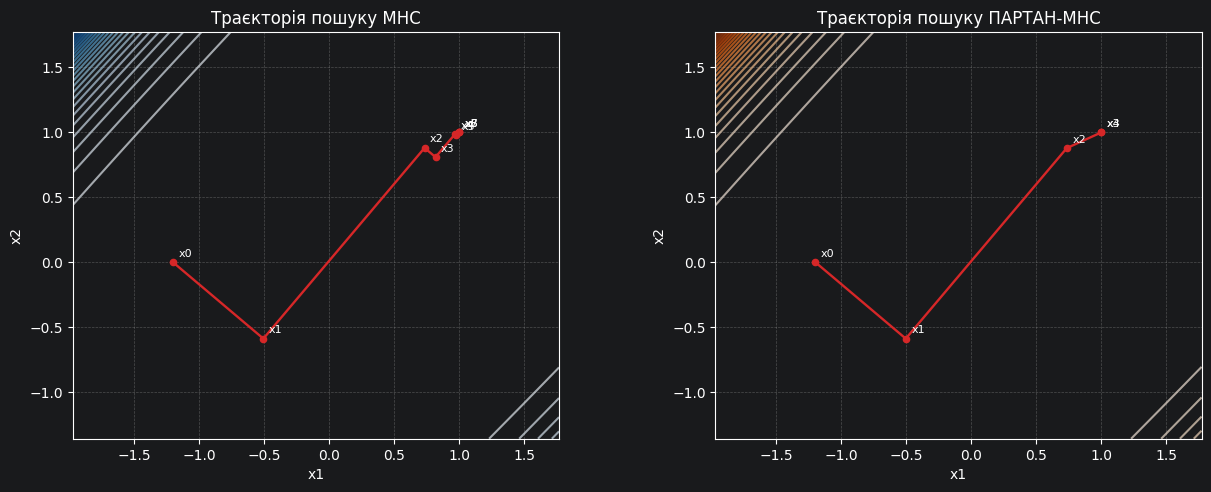

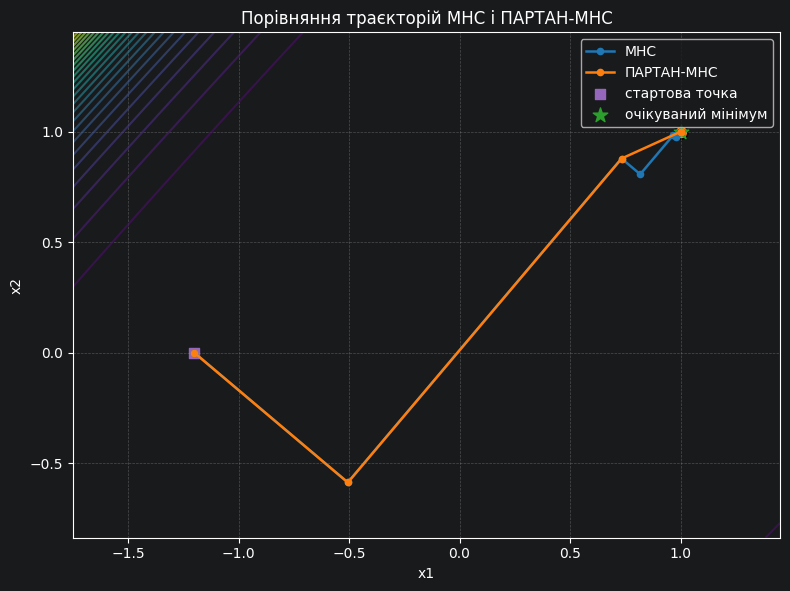

**Висновок.** ПАРТАН-МНС може рухатися до мінімуму іншою траєкторією та потребувати менше ітерацій для досягнення близької точки.

In [11]:
mns_result = steepest_descent(power_function, X_START, **base_params)
partan_result = partan_steepest_descent(power_function, X_START, **base_params)
trajectory_results = {"МНС": mns_result, "ПАРТАН-МНС": partan_result}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_trajectory(power_function, mns_result["points"], "Траєкторія пошуку МНС", cmap="Blues", ax=axes[0])
plot_trajectory(power_function, partan_result["points"], "Траєкторія пошуку ПАРТАН-МНС", cmap="Oranges", ax=axes[1])
plt.tight_layout()
plt.show()

plot_combined_trajectories(trajectory_results, "Порівняння траєкторій МНС і ПАРТАН-МНС")
display(Markdown("**Висновок.** ПАРТАН-МНС може рухатися до мінімуму іншою траєкторією та потребувати менше ітерацій для досягнення близької точки."))

## 5. Умовна оптимізація методом штрафних функцій

### 5.1. Пояснення методу

Метод штрафних функцій дозволяє розв’язувати задачу умовної оптимізації через послідовність задач безумовної оптимізації.

Початкова задача має вигляд:

`min f(x), при g(x) <= 0`.

Для цього будується допоміжна функція:

`F(x, r) = f(x) + r * P(x)`,

де `P(x)` — штраф за порушення обмеження.

У роботі використовується зовнішня штрафна функція:

`P(x) = max(0, g(x))^2`.

Якщо точка знаходиться всередині допустимої області, штраф дорівнює нулю. Якщо точка виходить за межі області, штраф зростає.

Конкретне обмеження:

`g(x) = x1^2 + x2^2 - 1 <= 0`.

### 5.2. Вплив коефіцієнта штрафу r

#### МНС

,початкова точка,коефіцієнт штрафу r,кінцева точка,значення початкової функції,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,кількість ітерацій,кількість викликів функції,статус
0,"[-1.20000000, 0.00000000]",1,"[0.71422751, 0.70008267]",4.900159e-05,4.905761e-05,2.366808e-04,2.366808e-04,1.183334e-04,22,1682,збіжність
1,"[-1.20000000, 0.00000000]",10,"[0.71415148, 0.70000813]",4.910250e-05,4.910812e-05,2.371359e-05,2.371359e-05,1.185672e-05,2,148,збіжність
2,"[-1.20000000, 0.00000000]",100,"[0.71414380, 0.70000072]",4.911262e-05,4.911318e-05,2.371804e-06,2.371804e-06,1.185901e-06,2,141,збіжність
3,"[-1.20000000, 0.00000000]",1000,"[0.71414303, 0.69999998]",4.911363e-05,4.911369e-05,2.371761e-07,2.371761e-07,1.185880e-07,2,131,збіжність
4,"[-1.20000000, 0.00000000]",10000,"[0.71414295, 0.69999990]",4.911373e-05,4.911374e-05,2.371776e-08,2.371776e-08,1.185888e-08,1,64,збіжність
5,"[-1.20000000, 0.00000000]",100000,"[0.71414295, 0.69999990]",4.911374e-05,4.911374e-05,2.370946e-09,2.370946e-09,1.185473e-09,1,59,збіжність


#### ПАРТАН-МНС

,початкова точка,коефіцієнт штрафу r,кінцева точка,значення початкової функції,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,кількість ітерацій,кількість викликів функції,статус
0,"[-1.20000000, 0.00000000]",1,"[0.71653164, 0.69771213]",4.954115e-05,4.958946e-05,2.198010e-04,2.198010e-04,1.098944e-04,7,463,збіжність
1,"[-1.20000000, 0.00000000]",10,"[0.71645723, 0.69764592]",4.963358e-05,4.963790e-05,2.078417e-05,2.078417e-05,1.039203e-05,3,226,збіжність
2,"[-1.20000000, 0.00000000]",100,"[0.71645043, 0.69763967]",4.964221e-05,4.964276e-05,2.330922e-06,2.330922e-06,1.165461e-06,2,141,збіжність
3,"[-1.20000000, 0.00000000]",1000,"[0.71644967, 0.69763895]",4.964320e-05,4.964325e-05,2.348463e-07,2.348463e-07,1.174231e-07,2,131,збіжність
4,"[-1.20000000, 0.00000000]",10000,"[0.71644959, 0.69763888]",4.964330e-05,4.964330e-05,2.350402e-08,2.350402e-08,1.175201e-08,1,64,збіжність
5,"[-1.20000000, 0.00000000]",100000,"[0.71644959, 0.69763887]",4.964331e-05,4.964331e-05,2.353445e-09,2.353445e-09,1.176722e-09,1,59,збіжність


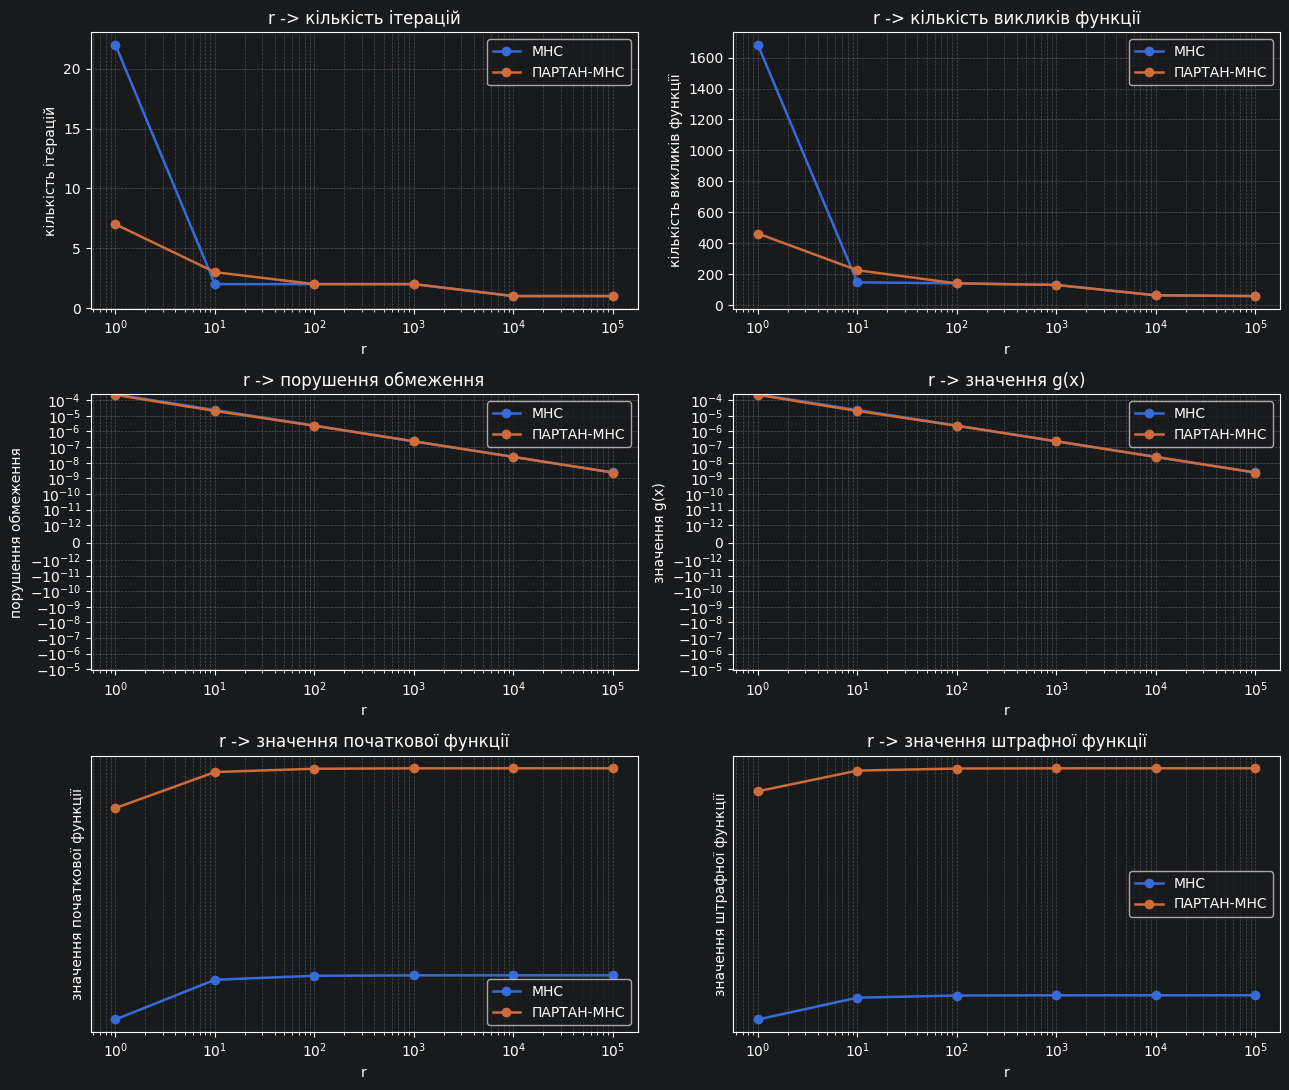

**Висновок.** При збільшенні коефіцієнта штрафу r порушення обмеження зменшується, але обчислювальна складність може зростати.

In [12]:
R_VALUES = (1, 10, 100, 1000, 10000, 100000)
penalty_tables = compare_penalty_methods(base_params=base_params, r_values=R_VALUES)
penalty_long = pd.concat(
    [table.assign(method=method_name) for method_name, table in penalty_tables.items()],
    ignore_index=True,
)

for method_name, table in penalty_tables.items():
    display(Markdown(f"#### {method_name}"))
    show_table(table)

metrics = [
    ("iterations", "кількість ітерацій", False),
    ("func_calls", "кількість викликів функції", False),
    ("violation", "порушення обмеження", True),
    ("constraint_value", "значення g(x)", True),
    ("f_original", "значення початкової функції", True),
    ("F_penalty", "значення штрафної функції", True),
]
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for ax, (metric, ylabel, log_y) in zip(axes.ravel(), metrics):
    plot_metric_by_parameter(
        penalty_long,
        parameter_col="r",
        metric_col=metric,
        title=f"r -> {ylabel}",
        xlabel="r",
        ylabel=ylabel,
        log_x=True,
        log_y=log_y,
        ax=ax,
    )
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** При збільшенні коефіцієнта штрафу r порушення обмеження зменшується, але обчислювальна складність може зростати."))

### 5.3. Порушення обмеження від r

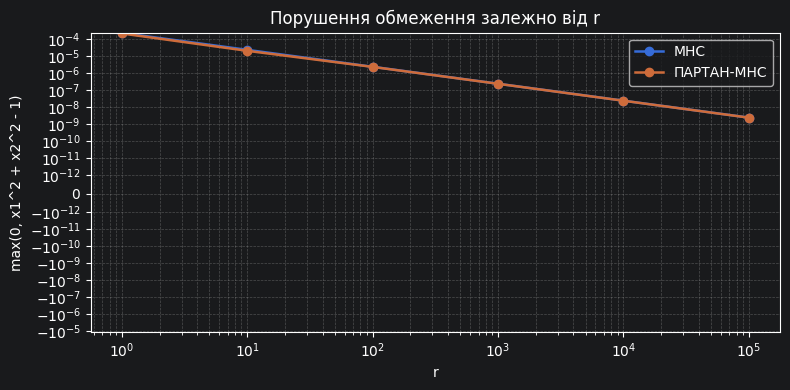

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric_by_parameter(
    penalty_long,
    parameter_col="r",
    metric_col="violation",
    title="Порушення обмеження залежно від r",
    xlabel="r",
    ylabel="max(0, x1^2 + x2^2 - 1)",
    log_x=True,
    log_y=True,
    ax=ax,
)
plt.tight_layout()
plt.show()

### 5.4. Відстань до межі від r

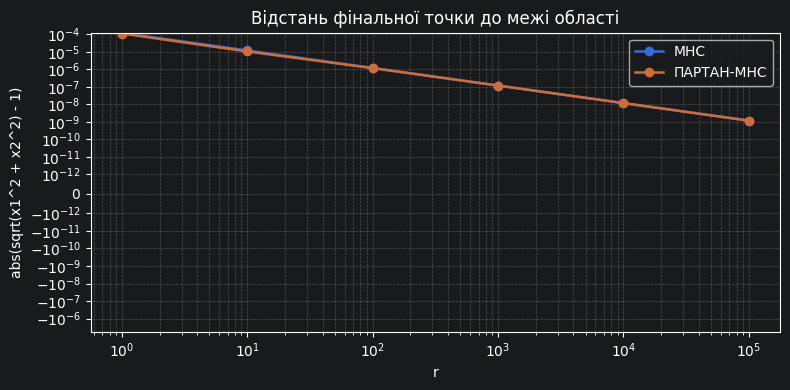

**Висновок.** Цей графік показує, наскільки близько фінальна точка знаходиться до межі допустимої області.

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric_by_parameter(
    penalty_long,
    parameter_col="r",
    metric_col="distance_to_boundary",
    title="Відстань фінальної точки до межі області",
    xlabel="r",
    ylabel="abs(sqrt(x1^2 + x2^2) - 1)",
    log_x=True,
    log_y=True,
    ax=ax,
)
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Цей графік показує, наскільки близько фінальна точка знаходиться до межі допустимої області."))

### 5.5. Координати фінальної точки від r

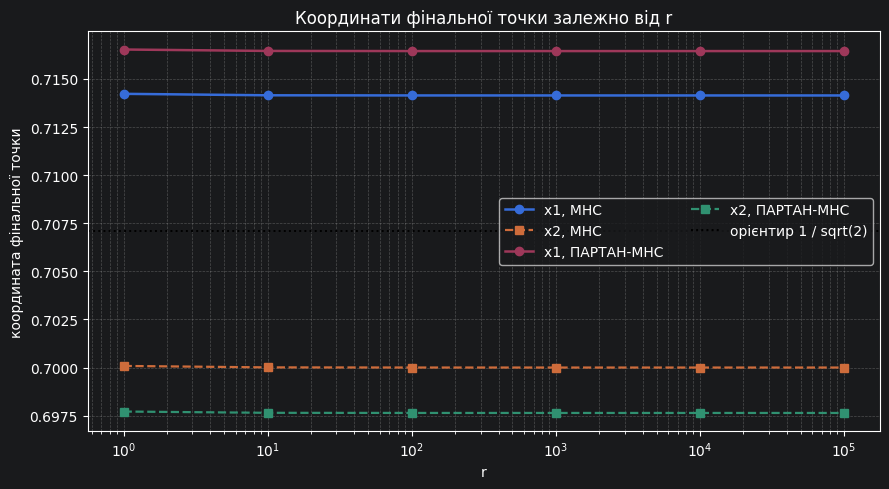

**Висновок.** Лінія `1 / sqrt(2)` використовується лише як орієнтир для точки на межі області в напрямку `(1; 1)`. Фактична фінальна точка визначається мінімумом заданої функції на межі круга, тому її координати не зобов’язані бути однаковими.

In [15]:
coordinate_rows = []
for method_name, table in penalty_tables.items():
    for _, row in table.iterrows():
        point = parse_point(row["x_final"])
        coordinate_rows.append({"method": method_name, "r": row["r"], "x1_final": point[0], "x2_final": point[1]})
coordinate_table = pd.DataFrame(coordinate_rows)

fig, ax = plt.subplots(figsize=(9, 5))
for method_name, group in coordinate_table.groupby("method", sort=False):
    ax.plot(group["r"], group["x1_final"], "o-", linewidth=1.8, label=f"x1, {method_name}")
    ax.plot(group["r"], group["x2_final"], "s--", linewidth=1.6, label=f"x2, {method_name}")
expected = 1 / np.sqrt(2)
ax.axhline(expected, color="black", linestyle=":", linewidth=1.4, label="орієнтир 1 / sqrt(2)")
ax.set_xscale("log")
ax.set_xlabel("r")
ax.set_ylabel("координата фінальної точки")
ax.set_title("Координати фінальної точки залежно від r")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Лінія `1 / sqrt(2)` використовується лише як орієнтир для точки на межі області в напрямку `(1; 1)`. Фактична фінальна точка визначається мінімумом заданої функції на межі круга, тому її координати не зобов’язані бути однаковими."))

### 5.6. Траєкторії штрафного методу

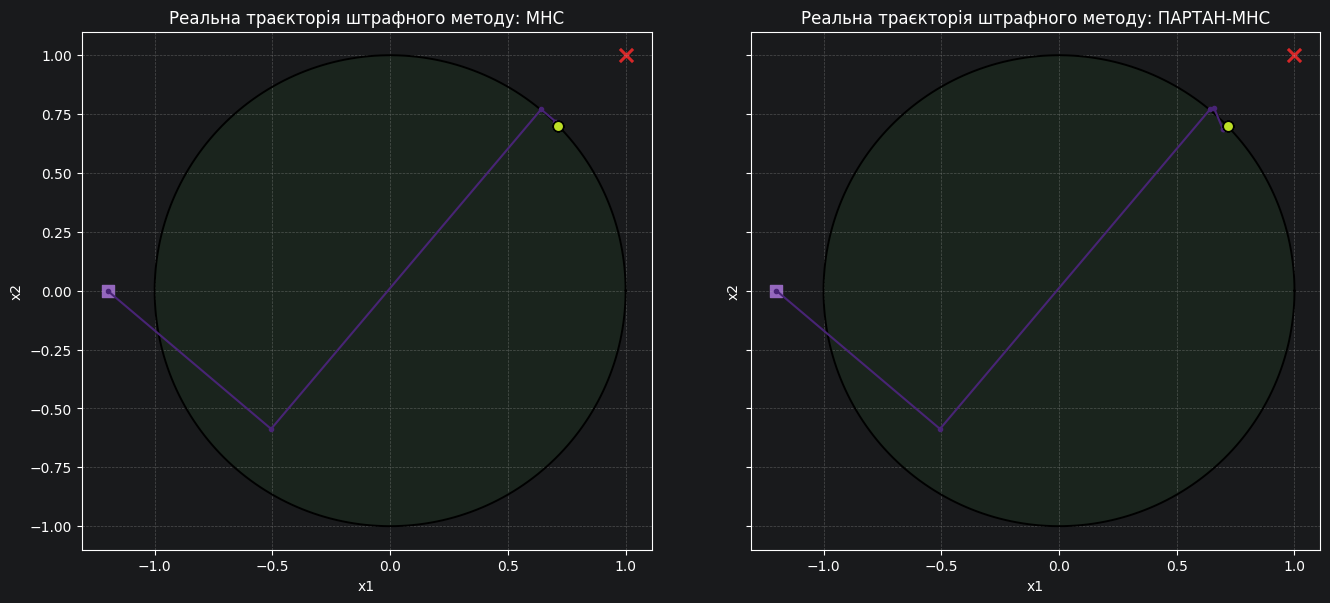

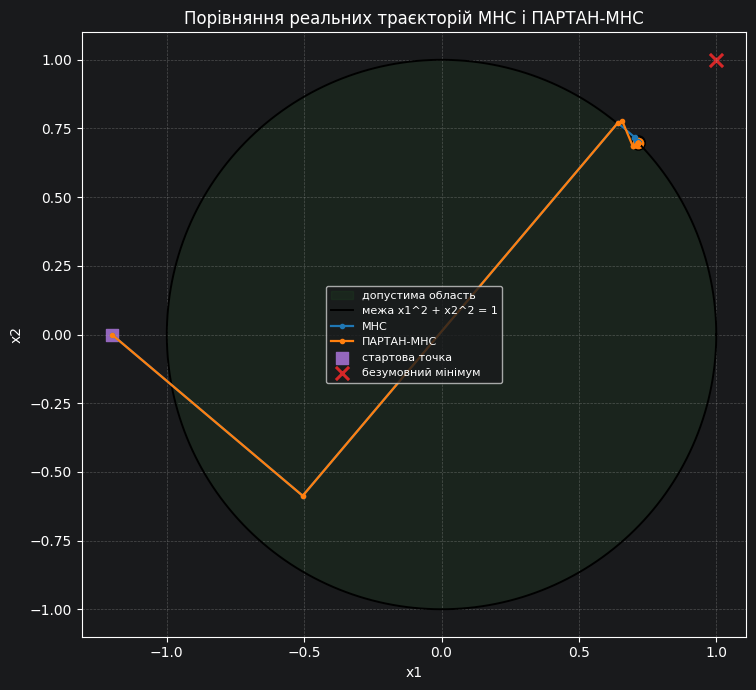

In [22]:
def penalty_stage_trajectories(method_fn, x_start, r_values):
    x_current = np.asarray(x_start, dtype=float).reshape(-1)
    stages = []
    for r in r_values:
        penalty_function = make_external_penalty_function(power_function, [circle_constraint], r)
        result = method_fn(penalty_function, x_current, **base_params)
        points = np.asarray(result["points"], dtype=float)
        stages.append((r, points))
        x_current = np.asarray(result["x_final"], dtype=float).reshape(-1)
    return stages


method_fns = {"МНС": steepest_descent, "ПАРТАН-МНС": partan_steepest_descent}
stage_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(R_VALUES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, (method_name, method_fn) in zip(axes, method_fns.items()):
    plot_circle_constraint(ax)
    stages = penalty_stage_trajectories(method_fn, X_START, R_VALUES)
    for (r, points), color in zip(stages, stage_colors):
        mark_every = max(1, len(points) // 18)
        ax.plot(
            points[:, 0],
            points[:, 1],
            "-o",
            color=color,
            linewidth=1.5,
            markersize=3,
            markevery=mark_every,
            label=f"r={r}",
        )
        ax.scatter(points[-1, 0], points[-1, 1], s=55, color=color, edgecolor="black", zorder=5)
    ax.scatter([X_START[0]], [X_START[1]], marker="s", s=70, color="tab:purple", label="старт")
    ax.scatter([1.0], [1.0], marker="x", s=90, color="tab:red", linewidths=2.2, label="безумовний мінімум")
    ax.set_title(f"Реальна траєкторія штрафного методу: {method_name}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
plot_circle_constraint(ax)
colors = {"МНС": "tab:blue", "ПАРТАН-МНС": "tab:orange"}
for method_name, method_fn in method_fns.items():
    stages = penalty_stage_trajectories(method_fn, X_START, R_VALUES)
    points = np.vstack([stage_points if i == 0 else stage_points[1:] for i, (_, stage_points) in enumerate(stages)])
    mark_every = max(1, len(points) // 25)
    ax.plot(
        points[:, 0],
        points[:, 1],
        "-o",
        linewidth=1.6,
        markersize=3,
        markevery=mark_every,
        color=colors[method_name],
        label=method_name,
    )
    ax.scatter(points[-1, 0], points[-1, 1], s=90, color=colors[method_name], edgecolor="black", linewidth=1.0)
ax.scatter([X_START[0]], [X_START[1]], marker="s", s=70, color="tab:purple", label="стартова точка")
ax.scatter([1.0], [1.0], marker="x", s=90, color="tab:red", linewidths=2.2, label="безумовний мінімум")
ax.set_title("Порівняння реальних траєкторій МНС і ПАРТАН-МНС")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.7. Вплив початкової точки

,метод,початкова точка,кінцева точка,значення початкової функції,значення обмеження g(x),порушення обмеження,відстань до межі області,сумарна кількість ітерацій,сумарна кількість викликів функції,статус
0,МНС,"[-1.50000000, 0.00000000]","[0.71414238, 0.70000049]",4.911373e-05,2.372052e-08,2.372052e-08,1.186026e-08,27,2004,збіжність
1,МНС,"[1.50000000, 0.00000000]","[0.71414272, 0.70000014]",4.911373e-05,2.371656e-08,2.371656e-08,1.185828e-08,15,1082,збіжність
2,МНС,"[0.00000000, 1.50000000]","[0.71414265, 0.70000021]",4.911373e-05,2.371981e-08,2.371981e-08,1.185990e-08,19,1406,збіжність
3,МНС,"[-1.00000000, -1.00000000]","[0.71412202, 0.70002126]",4.911379e-05,2.372298e-08,2.372298e-08,1.186149e-08,239,18603,збіжність
4,МНС,"[2.00000000, 2.00000000]","[0.71414556, 0.69999724]",4.911373e-05,2.371897e-08,2.371897e-08,1.185949e-08,20,1483,збіжність
5,ПАРТАН-МНС,"[-1.50000000, 0.00000000]","[0.71779421, 0.69625534]",5.045271e-05,2.349726e-08,2.349726e-08,1.174863e-08,15,1024,збіжність
6,ПАРТАН-МНС,"[1.50000000, 0.00000000]","[0.71363408, 0.70051868]",4.913971e-05,2.380404e-08,2.380404e-08,1.190202e-08,11,743,збіжність
7,ПАРТАН-МНС,"[0.00000000, 1.50000000]","[0.71414337, 0.69999948]",4.911373e-05,2.371863e-08,2.371863e-08,1.185931e-08,15,1067,збіжність
8,ПАРТАН-МНС,"[-1.00000000, -1.00000000]","[0.71411719, 0.70002619]",4.911382e-05,2.372324e-08,2.372324e-08,1.186162e-08,12,820,збіжність
9,ПАРТАН-МНС,"[2.00000000, 2.00000000]","[0.71435648, 0.69978200]",4.911811e-05,2.368771e-08,2.368771e-08,1.184386e-08,12,842,збіжність


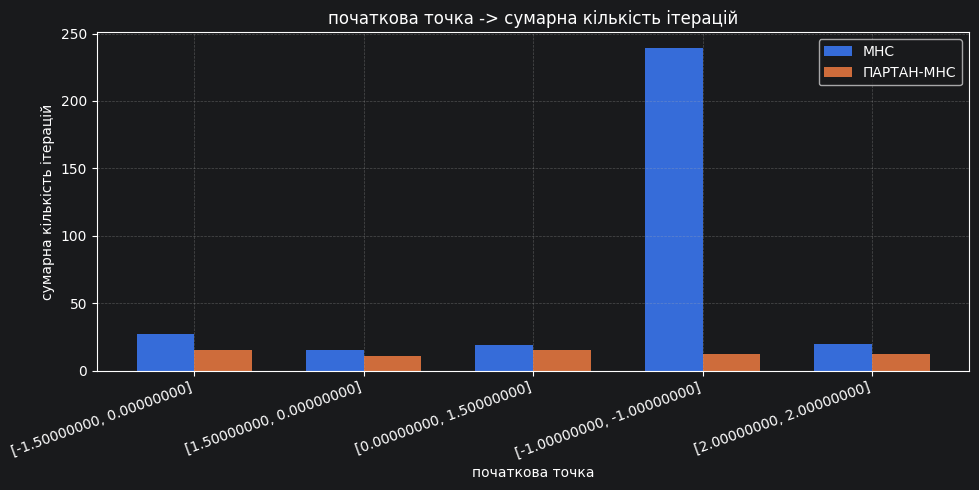

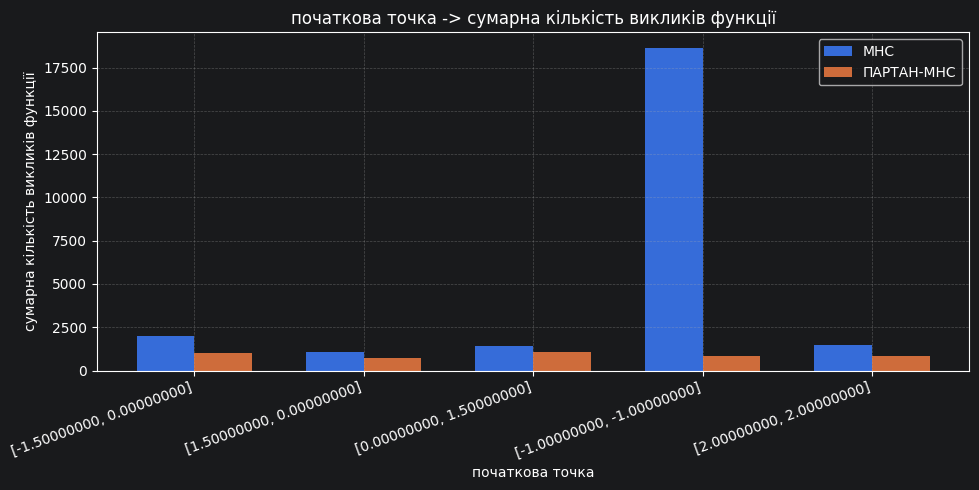

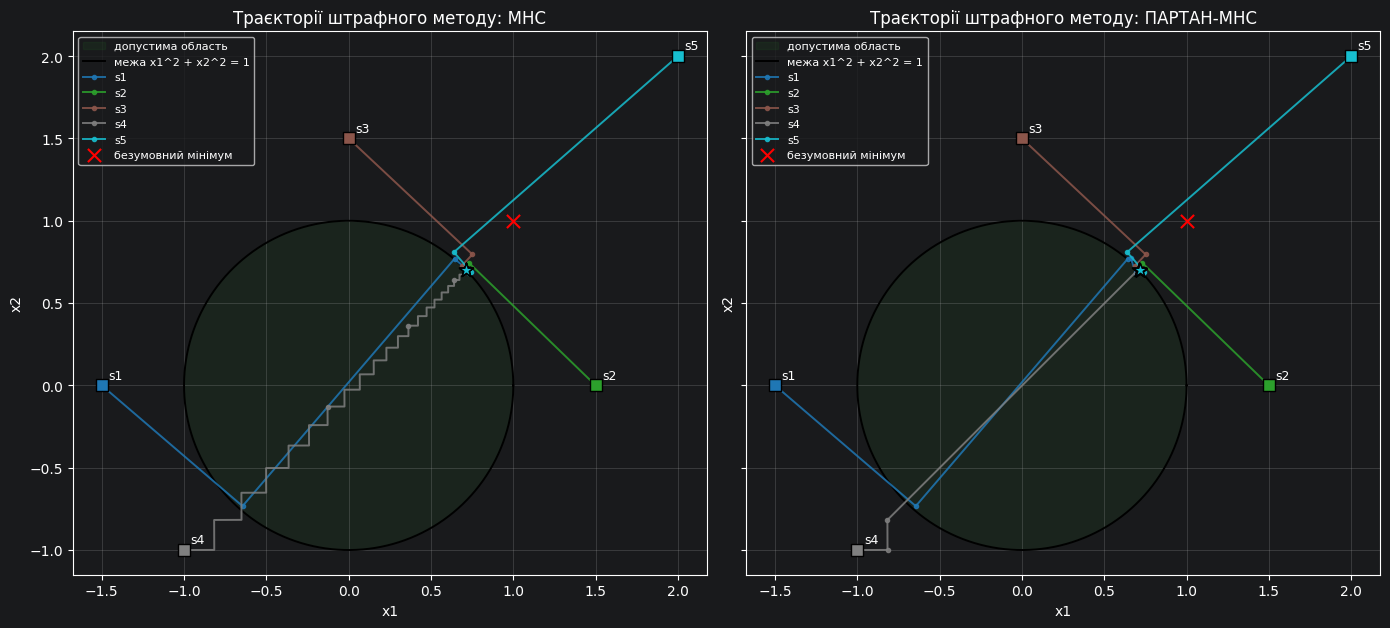

**Висновок.** Початкова точка впливає насамперед на трудомісткість методу: кількість ітерацій і викликів функції. Траєкторії показують реальний шлях внутрішніх ітерацій штрафного методу до близької ділянки межі допустимої області.

In [17]:
penalty_start_points = [
    [-1.5, 0.0],
    [1.5, 0.0],
    [0.0, 1.5],
    [-1.0, -1.0],
    [2.0, 2.0],
]
start_point_table = compare_penalty_start_points(
    base_params=base_params,
    start_points=penalty_start_points,
    r_values=(1, 10, 100, 1000, 10000),
)
show_table(start_point_table)

start_plot_table = start_point_table.copy()
start_plot_table["start_label"] = start_plot_table["x_start"]
for metric, ylabel in [
    ("iterations_total", "сумарна кількість ітерацій"),
    ("func_calls_total", "сумарна кількість викликів функції"),
]:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_metric_by_parameter(
        start_plot_table,
        parameter_col="start_label",
        metric_col=metric,
        title=f"початкова точка -> {ylabel}",
        xlabel="початкова точка",
        ylabel=ylabel,
        log_y=False,
        ax=ax,
    )
    plt.tight_layout()
    plt.show()

def penalty_optimization_points(method_fn, x_start, r_values):
    x_current = np.asarray(x_start, dtype=float).reshape(-1)
    all_points = []
    for r in r_values:
        penalty_function = make_external_penalty_function(power_function, [circle_constraint], r)
        result = method_fn(penalty_function, x_current, **base_params)
        points = np.asarray(result["points"], dtype=float)
        if all_points:
            points = points[1:]
        all_points.extend(points)
        x_current = np.asarray(result["x_final"], dtype=float).reshape(-1)
    return np.vstack(all_points)


trajectory_r_values = (1, 10, 100, 1000, 10000)
start_points_array = np.array(penalty_start_points, dtype=float)
start_colors = plt.cm.tab10(np.linspace(0, 1, len(start_points_array)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, (method_name, method_fn) in zip(axes, [("МНС", steepest_descent), ("ПАРТАН-МНС", partan_steepest_descent)]):
    plot_circle_constraint(ax)
    for index, (x_start, color) in enumerate(zip(start_points_array, start_colors), start=1):
        points = penalty_optimization_points(method_fn, x_start, trajectory_r_values)
        mark_every = max(1, len(points) // 20)
        ax.plot(
            points[:, 0],
            points[:, 1],
            "-o",
            color=color,
            linewidth=1.4,
            markersize=3,
            markevery=mark_every,
            alpha=0.85,
            label=f"s{index}",
        )
        ax.scatter(points[0, 0], points[0, 1], marker="s", s=65, color=color, edgecolor="black", zorder=6)
        ax.scatter(points[-1, 0], points[-1, 1], marker="*", s=110, color=color, edgecolor="black", zorder=7)
        ax.annotate(f"s{index}", points[0] + np.array([0.04, 0.04]), fontsize=9)
    ax.scatter([1], [1], marker="x", s=90, color="red", label="безумовний мінімум", zorder=8)
    ax.set_title(f"Траєкторії штрафного методу: {method_name}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Початкова точка впливає насамперед на трудомісткість методу: кількість ітерацій і викликів функції. Траєкторії показують реальний шлях внутрішніх ітерацій штрафного методу до близької ділянки межі допустимої області."))

### 5.8. Порівняння МНС і ПАРТАН-МНС для штрафної функції

,метод,фінальний коефіцієнт штрафу r,кінцева точка,значення початкової функції,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,сумарна кількість ітерацій,сумарна кількість викликів функції,статус
0,МНС,100000,"[0.71414295, 0.69999990]",4.911374e-05,4.911374e-05,2.370946e-09,2.370946e-09,1.185473e-09,30,2225,збіжність
1,ПАРТАН-МНС,100000,"[0.71644959, 0.69763887]",4.964331e-05,4.964331e-05,2.353445e-09,2.353445e-09,1.176722e-09,16,1084,збіжність


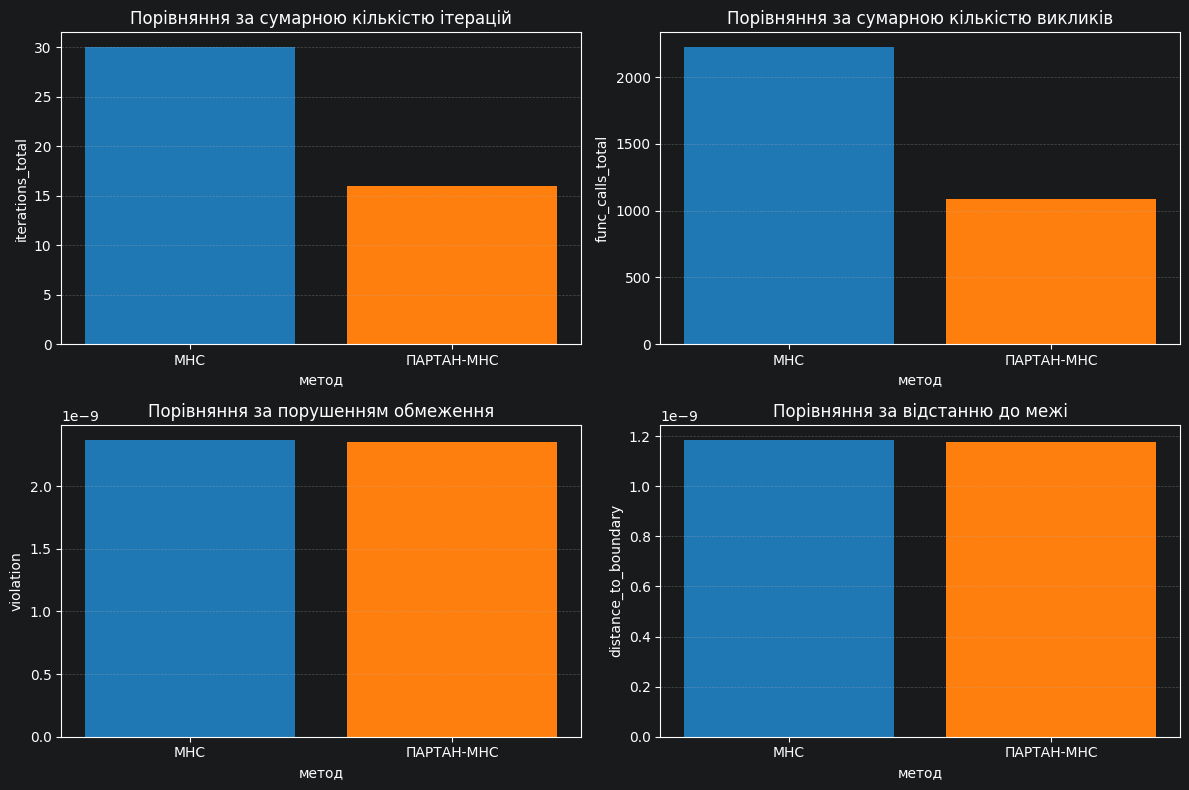

**Висновок.** Порівняння показує, який метод швидше розв’язує штрафну задачу та який метод дає менше порушення обмеження.

In [18]:
penalty_summary = pd.DataFrame([
    penalty_experiment_summary(table, method=method_name)
    for method_name, table in penalty_tables.items()
])
show_table(penalty_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric, title in [
    (axes[0, 0], "iterations_total", "Порівняння за сумарною кількістю ітерацій"),
    (axes[0, 1], "func_calls_total", "Порівняння за сумарною кількістю викликів"),
    (axes[1, 0], "violation", "Порівняння за порушенням обмеження"),
    (axes[1, 1], "distance_to_boundary", "Порівняння за відстанню до межі"),
]:
    plot_final_comparison(penalty_summary, metric, title, ax=ax)
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Порівняння показує, який метод швидше розв’язує штрафну задачу та який метод дає менше порушення обмеження."))

## 6. Фінальне порівняння

In [19]:
unconstrained_final = comparison_table.copy()
unconstrained_final["task"] = "безумовна оптимізація"
unconstrained_final["r_final"] = "-"
unconstrained_final["F_penalty"] = "-"
unconstrained_final["constraint_value"] = "-"
unconstrained_final["violation"] = "-"
unconstrained_final["distance_to_boundary"] = "-"
unconstrained_final["iterations_total"] = unconstrained_final["iterations"]
unconstrained_final["func_calls_total"] = unconstrained_final["func_calls"]

penalty_final = penalty_summary.copy()
penalty_final["task"] = "штрафна функція"
penalty_final["f_final"] = penalty_final["f_original"]
penalty_final["grad_norm_final"] = "-"

final_comparison = pd.concat([
    unconstrained_final[["task", "method", "r_final", "x_final", "f_final", "grad_norm_final", "F_penalty", "constraint_value", "violation", "distance_to_boundary", "iterations_total", "func_calls_total", "status"]],
    penalty_final[["task", "method", "r_final", "x_final", "f_final", "grad_norm_final", "F_penalty", "constraint_value", "violation", "distance_to_boundary", "iterations_total", "func_calls_total", "status"]],
], ignore_index=True)

show_table(final_comparison)

,задача,метод,фінальний коефіцієнт штрафу r,кінцева точка,кінцеве значення функції,норма градієнта,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,сумарна кількість ітерацій,сумарна кількість викликів функції,статус
0,безумовна оптимізація,МНС,-,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,-,-,-,-,8,1227,збіжність
1,безумовна оптимізація,ПАРТАН-МНС,-,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,-,-,-,-,4,199,збіжність
2,штрафна функція,МНС,100000,"[0.71414295, 0.69999990]",4.911374e-05,-,4.911374e-05,2.370946e-09,2.370946e-09,1.185473e-09,30,2225,збіжність
3,штрафна функція,ПАРТАН-МНС,100000,"[0.71644959, 0.69763887]",4.964331e-05,-,4.964331e-05,2.353445e-09,2.353445e-09,1.176722e-09,16,1084,збіжність


## 7. Контроль через старі SymPy-версії

Цей блок потрібен лише для перевірки траєкторій. Старі реалізації використовують аналітичні похідні та точний пошук кроку через SymPy, тому кількість ітерацій обмежена.

,метод,кінцева точка,кінцеве значення функції,норма градієнта,кількість ітерацій,кількість викликів функції,статус,джерело
0,МНС,"[0.99731800, 0.99717248]",3.006597e-21,6.455543e-18,8,1227,збіжність,поточна NumPy-версія
1,ПАРТАН-МНС,"[0.99998883, 0.99998678]",7.731213e-40,1.926863e-25,4,199,збіжність,поточна NumPy-версія
2,МНС SymPy,"[0.96765818, 0.98529917]",2.989199e-10,1.571846e-07,5,-,контроль,стара SymPy-версія
3,ПАРТАН-МНС SymPy,"[1.00343168, 1.00155986]",4.802803e-18,2.380167e-14,4,-,контроль,стара SymPy-версія


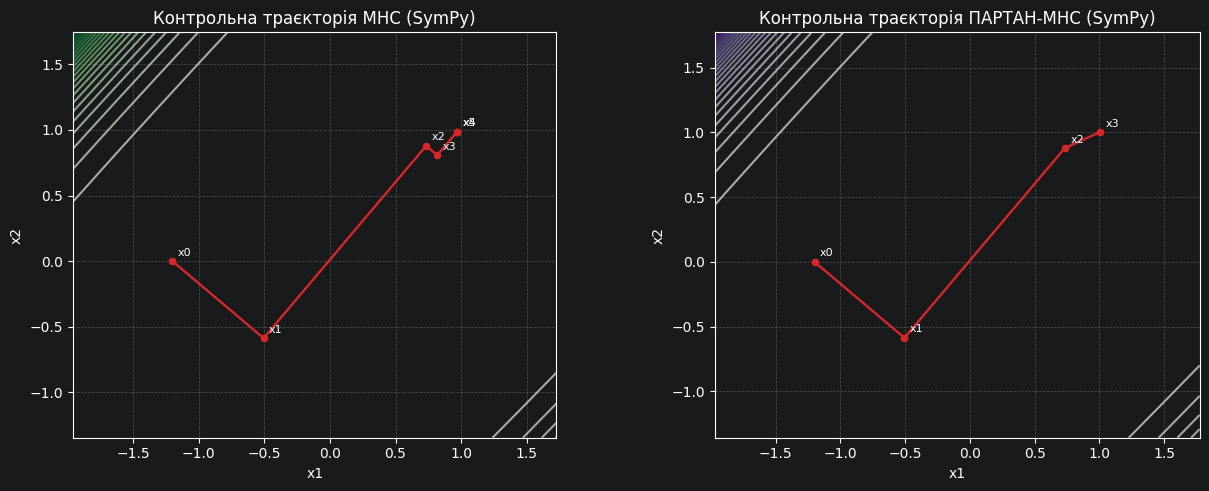

In [20]:
old_check = old_sympy_check(max_iter_mns=10, max_iter_partan=10, eps=1e-6)
current_check = compare_methods(BASE_PARAMS)
current_check["джерело"] = "поточна NumPy-версія"
old_table = old_check["table"].copy()
old_table["джерело"] = "стара SymPy-версія"
show_table(pd.concat([current_check, old_table], ignore_index=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_trajectory(power_function, old_check["mns_points"], "Контрольна траєкторія МНС (SymPy)", cmap="Greens", ax=axes[0])
plot_trajectory(power_function, old_check["partan_points"], "Контрольна траєкторія ПАРТАН-МНС (SymPy)", cmap="Purples", ax=axes[1])
plt.tight_layout()
plt.show()

### 7.1. Контроль проблемної точки s4 для штрафної функції

Для точки `s4 = [-1; -1]` додатково перевіряємо МНС за допомогою аналітичного градієнта SymPy для зовнішньої штрафної функції з `Piecewise(max(0, g)^2)`. Якщо кількість ітерацій залишається великою, причина не в чисельному градієнті, а у зигзагоподібній поведінці самого МНС.

,метод,початкова точка,коефіцієнт штрафу r,кінцева точка,значення штрафної функції,норма градієнта,кількість ітерацій,кількість викликів функції,статус
0,МНС NumPy,"[-1.00000000, -1.00000000]",1,"[0.71420639, 0.70010389]",4.905765e-05,3.490774e-06,232,18119,збіжність
1,МНС SymPy-gradient,"[-1.00000000, -1.00000000]",1,"[0.71420857, 0.70010247]",4.905765e-05,3.785889e-06,239,17752,збіжність


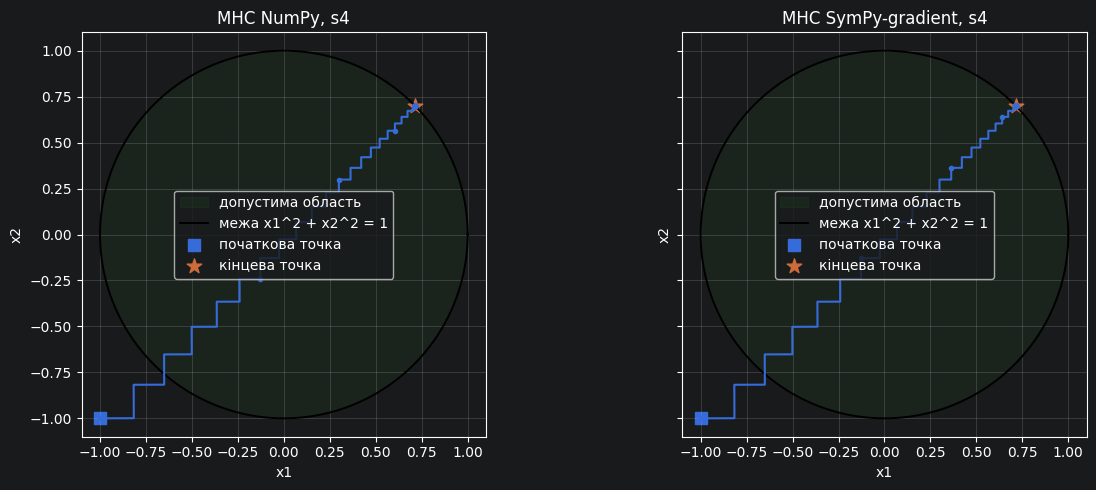

**Висновок.** Аналітичний градієнт SymPy дає практично таку саму довгу траєкторію для `s4`, як і NumPy-версія. Отже, велика кількість ітерацій пояснюється не помилкою чисельного диференціювання, а властивістю МНС для цієї початкової точки.

In [21]:
s4_sympy_check = sympy_penalty_s4_check(BASE_PARAMS)
show_table(s4_sympy_check["table"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, title, points in [
    (axes[0], "МНС NumPy, s4", s4_sympy_check["numpy"]["points"]),
    (axes[1], "МНС SymPy-gradient, s4", s4_sympy_check["sympy"]["points"]),
]:
    plot_circle_constraint(ax)
    mark_every = max(1, len(points) // 20)
    ax.plot(points[:, 0], points[:, 1], "-o", markersize=3, markevery=mark_every)
    ax.scatter(points[0, 0], points[0, 1], marker="s", s=70, label="початкова точка")
    ax.scatter(points[-1, 0], points[-1, 1], marker="*", s=120, label="кінцева точка")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Аналітичний градієнт SymPy дає практично таку саму довгу траєкторію для `s4`, як і NumPy-версія. Отже, велика кількість ітерацій пояснюється не помилкою чисельного диференціювання, а властивістю МНС для цієї початкової точки."))

## 8. Висновки

У роботі було досліджено метод найшвидшого спуску та метод ПАРТАН-МНС для задачі безумовної оптимізації.

Було перевірено вплив кроку чисельного диференціювання, схеми обчислення похідних, методу одновимірного пошуку, точності одновимірного пошуку, параметра методу Свена та критерію зупинки.

Також було реалізовано метод зовнішніх штрафних функцій для задачі умовної оптимізації з обмеженням `x1^2 + x2^2 <= 1`.

Експерименти показали, що при збільшенні коефіцієнта штрафу `r` порушення обмеження зменшується, а фінальна точка наближається до межі допустимої області `x1² + x2² = 1`.

Порівняння МНС і ПАРТАН-МНС дозволило оцінити різницю між методами за кількістю ітерацій, кількістю викликів функції та точністю отриманого результату.